Task 3 (Basic): Data annotation and Creating a dataset

Part A:

In [1]:
# getting the sample 
!wget https://raw.githubusercontent.com/TurkuNLP/intro-to-nlp/refs/heads/master/Data/emotion-sample.tsv

--2026-03-31 19:08:50--  https://raw.githubusercontent.com/TurkuNLP/intro-to-nlp/refs/heads/master/Data/emotion-sample.tsv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 2089 (2,0K), 2 remaining [text/plain]
Saving to: ‘emotion-sample.tsv’

emotion-sample.tsv  100%[+++++++++++++++++++>]   2,04K  --.-KB/s    in 0s      

2026-03-31 19:08:51 (120 KB/s) - ‘emotion-sample.tsv’ saved [2089/2089]



In [2]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import re

Next I'm going to read the files, and by using regex to extract all labels by using whitespaces. I also replace the number labels to their string representation:

In [16]:
regex = re.compile(r'\s\d\s', re.IGNORECASE)
listOfLablels = list()
originalLabels = list()

with open("emotion-sample.tsv") as f1:
    for line in f1.readlines():
        listOfLablels.append(regex.findall(line))

for labelList in listOfLablels:
    for label in labelList:
        originalLabels.append(re.sub(r'\s', '', label)
                      .replace('0', 'sadness')
                      .replace('1', 'joy')
                      .replace('2', 'love')
                      .replace('3', 'anger')
                      .replace('4', 'fear')
                      .replace('5', 'surprise'))
        
print(originalLabels)

myLabels = list()
listOfLablels = list()

with open("emotion-sample-mine.tsv") as f2:
    for line in f2.readlines():
        listOfLablels.append(regex.findall(line))

for labelList in listOfLablels:
    for label in labelList:
        myLabels.append(re.sub(r'\s', '', label)
                      .replace('0', 'sadness')
                      .replace('1', 'joy')
                      .replace('2', 'love')
                      .replace('3', 'anger')
                      .replace('4', 'fear')
                      .replace('5', 'surprise'))
        
print(myLabels)

['fear', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'joy', 'sadness', 'fear', 'sadness', 'love', 'sadness', 'sadness', 'joy', 'sadness', 'joy', 'anger', 'love', 'fear', 'sadness']
['joy', 'joy', 'anger', 'sadness', 'sadness', 'sadness', 'joy', 'sadness', 'sadness', 'love', 'sadness', 'sadness', 'sadness', 'joy', 'sadness', 'sadness', 'love', 'joy', 'love', 'sadness']


In [17]:
cohenKappa = cohen_kappa_score(originalLabels,myLabels)

In [18]:
print(cohenKappa)

0.18644067796610164


In [19]:
confusionMatrix = confusion_matrix(originalLabels,myLabels)

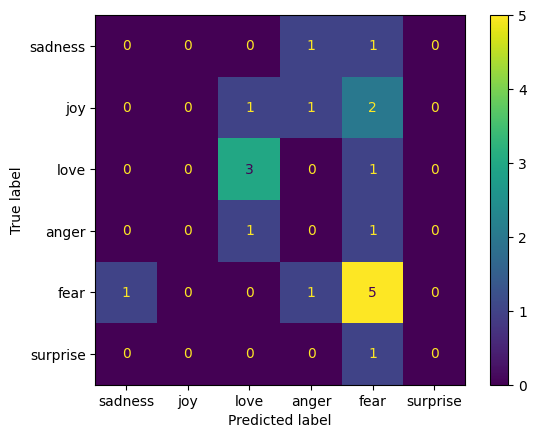

In [20]:
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

disp = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix,
                              display_labels=labels)
disp.plot()

plt.show()

Part B:

In [21]:
# getting the samples
!wget http://dl.turkunlp.org/TKO_7095_2023/imdb-positives.txt
!wget http://dl.turkunlp.org/TKO_7095_2023/imdb-negatives.txt

--2026-03-31 19:38:38--  http://dl.turkunlp.org/TKO_7095_2023/imdb-positives.txt
Resolving dl.turkunlp.org (dl.turkunlp.org)... 195.148.30.23
Connecting to dl.turkunlp.org (dl.turkunlp.org)|195.148.30.23|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33151188 (32M) [text/plain]
Saving to: ‘imdb-positives.txt’

imdb-positives.txt  100%[===================>]  31,62M  23,0MB/s    in 1,4s    

2026-03-31 19:38:39 (23,0 MB/s) - ‘imdb-positives.txt’ saved [33151188/33151188]

--2026-03-31 19:38:40--  http://dl.turkunlp.org/TKO_7095_2023/imdb-negatives.txt
Resolving dl.turkunlp.org (dl.turkunlp.org)... 195.148.30.23
Connecting to dl.turkunlp.org (dl.turkunlp.org)|195.148.30.23|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32382320 (31M) [text/plain]
Saving to: ‘imdb-negatives.txt’

imdb-negatives.txt  100%[===================>]  30,88M  22,3MB/s    in 1,4s    

2026-03-31 19:38:41 (22,3 MB/s) - ‘imdb-negatives.txt’ saved [32382320/32382320]

In [23]:
import datasets

In [22]:
with open("imdb-positives.txt") as positive:
    for line in positive.readlines()[:10]:
        print(line)

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but intriguing, and frightening.

Zentropa is the most original movie I've seen in years. If you like unique thrillers that are influenced by film noir, then this is just the right cure for all of those Hollywood summer blockbusters clogging the theaters these days. Von Trier's follow-ups like Breaking 

In [ ]:
positiveData = list()
positiveLabels = list()

with open("imdb-positives.txt") as positive:
    for line in positive.readlines():
        positiveData.append(line)
        positiveLabels.append('positive')

negativeData = list()
negativeLabels = list()

with open("imdb-negatives.txt") as negative:
    for line in negative.readlines():
        negativeData.append(line)
        negativeLabels.append('negative')

In [31]:
trainSize: int = int(len(positiveData) * 0.8)
print(trainSize)
testSize: int = int(len(positiveData) * 0.9)
print(testSize)

20000
22500


In [33]:
trainPos, testPos, valPos = list(), list(), list()
trainNeg, testNeg, valNeg = list(), list(), list()

trainPos = positiveData[:trainSize]
testPos = positiveData[trainSize:testSize]
valPos = positiveData[testSize:]

print(len(trainPos))
print(len(testPos))
print(len(valPos))

trainNeg = negativeData[:trainSize]
testNeg = negativeData[trainSize:testSize]
valNeg = negativeData[testSize:]

print(len(trainNeg))
print(len(testNeg))
print(len(valNeg))

20000
2500
2500
20000
2500
2500


In [ ]:
def posgen():
    for 